In [2]:
import sympy
import numpy as np
import pandas as pd
from sympy import latex, Matrix, symbols, lambdify, S
import matplotlib.pyplot as plt
from IPython.display import Latex
from google.colab import files
from skimage import io

# Практическое занятие 13
# Компьютерный практикум по алгебре на Python

## Собственные числа и собственные векторы линейного оператора.
### Задание 1.
Описать функцию одного обязательного аргумента - матрицы $A$, возвращающую максимальное по модулю собственное число и соответствующий собственный вектор матрицы.

Вывести на экран все собственные числа и собственные векторы матрицы
$$
\left(\begin{matrix}
1 & 0 & 0 & -2\\
0 & 1 & 0 & 1\\
0 & 0 & 2 & 1\\
-1 & 0 & 0 & 1
\end{matrix}\right)
$$

Записать в файл .tex максимальное по модулю собственное число и соответствующий собственный вектор.



In [ ]:
def find_max_value_vector(A):
    eigenvects = A.eigenvects()
    max_modulus = 0
    max_eigenvalue = None
    output_vector = None
    for eigenvalue, multiplicity, vectors in eigenvects:
        if abs(eigenvalue) > abs(max_modulus):
            max_modulus = abs(eigenvalue)
            output_vector = vectors[0]
    return max_modulus, output_vector

In [ ]:
B = Matrix([[1, 0, 0, -2], [0, 1, 0, 1], [0, 0, 2, 1], [-1, 0, 0, 1]])
res1, res2 = find_max_value_vector(B)
display(Latex(latex(res1)))

<IPython.core.display.Latex object>

In [ ]:
display(Latex(latex(res2)))

<IPython.core.display.Latex object>

In [ ]:
text = """ \\documentclass[11pt]{report}\n
\\usepackage[T2A]{fontenc}\n
\\usepackage[utf8]{inputenc}\n
\\usepackage[russian]{babel}\n
\\usepackage{amsmath,amssymb}\n
\\begin{document}\n
{\\bf Пример 1.}\n\n"""
end_text = "\n\n\\end{document}"
fname = 'sem_13_exercise_1.tex'
with open(fname, 'w', encoding='utf-8') as f:
    f.write(text + latex(res1, mode='inline') + latex(res2, mode='inline') + end_text)

## Собственные векторы numpy
### Задание 2.
Считать матрицу $A$ из файла 'sem_13_task_2.xlsx'.

Вывести на экран собственные числа и собственные векторы этой матрицы.

Записать в файл 'sem_13_task_2_ans.xlsx' собственные числа и собственные векторы матрицы $A$  на отдельные листы, так что имя листа это собственное число, округленное до целого, а собственный вектор записан в строку, подписей строк и столбцов нет.

In [52]:
uploaded = files.upload()
for file_name in uploaded.keys():
    display(Latex(f'Загружен\ файл\ {latex(file_name)}'))

Saving sem_13_task_2.xlsx to sem_13_task_2.xlsx


<IPython.core.display.Latex object>

In [53]:
matrix_data = pd.read_excel(file_name, header=None)
A = np.array(matrix_data.values)
A

array([[ 2,  0,  0, -2],
       [ 0, -1,  0,  3],
       [ 0,  0,  5,  4],
       [-2,  0,  0,  2]])

In [ ]:
A_eigen_vals, A_eigen_vects = np.linalg.eig(A)
display(Latex(f'Собственные\ векторы:'))
display(Latex(f'{latex(A_eigen_vects)}'))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [ ]:
display(Latex(f'Собственные\ числа:'))
display(Latex(f'{latex(A_eigen_vals)}'))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [ ]:
output_file_name = "sem_13_task_2_ans.xlsx"
with pd.ExcelWriter(output_file_name) as writer:
    for num in range(4):
        name_sheet = np.round(A_eigen_vals[num])
        pd.DataFrame(A_eigen_vects[num]).to_excel(writer, sheet_name=f'{name_sheet}', index=False, header=False)
files.download(output_file_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Сингулярное разложение (SVD)
## Задание 3
Найти SVD матрицы $A$ Задания 2 с помощью np.linalg.svd.

Вывести на экран все элементы разложения, показать, что получено разложение именно матрицы $A$.

Проверить, что квадраты диагональных элементов матрицы $\Sigma$ являются собственными числами матрицы $A^TA$, проверка с помощью определителя $|A - \lambda E|$.

In [ ]:
U, sigma, Vh = np.linalg.svd(A, full_matrices=True)
Sig = np.zeros((U.shape[0], Vh.shape[0]))
Sig[:len(sigma), :len(sigma)] = np.diag(sigma)
matr_dict = {'A': A, 'V^T': Vh, '\sigma': sigma, 'U': U, '\Sigma': Sig,
             'U\Sigma V^T': U @ Sig @ Vh}
for key in matr_dict.keys():
    display(Latex(f'{key} = {sympy.latex(Matrix((matr_dict[key]).round(2)))}'))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [ ]:
ATA = Matrix(A.T @ A)
E = Matrix(np.eye(len(Sig)))
list_gamma = [Sig[i][j] ** 2 for i in range(len(Sig)) for j in range(len(Sig[i])) if j == i]
for gamma in list_gamma:
  display(Latex(f'{latex((ATA - gamma * E).det())}'))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

## Задание 4*
Используя разложение SVD матрицы $A$ Задания 2, полученное в Задании 3, показать, что столбцы матрицы $U$ ортогональны, т.е. их скалярное произведение 0. (Подсказка - перемножить транспонированный столбец на другой столбец).

Проверить, что квадраты диагональных элементов матрицы $\Sigma$ являются собственными числами матрицы $A^TA$, соответствующим собственным векторам, записанным в строках матрицы $Vh$ разложения  SVD, т.е. что $A^TAx - \lambda x$ вектор из машинных нулей, где $x$ строка матрицы $Vh$, записанная в столбец (чтобы можно было перемножить $A^TAx$).

Показать, что если $x$ собственный вектор, $\sigma$ - ненулевое собственное число матрицы $A^TA$, то $\frac{1}{\sigma}A x$ с точностью до машинного нуля совпадает со столбцом матрицы $U$, соответствующим $\sigma$.

In [ ]:
res1= np.dot(U.T, U)
display(res1)
display(Latex(f'{np.allclose(res1, np.eye(U.shape[1]))}'))

array([[ 1.00000000e+00, -9.25255551e-17, -2.27922694e-16,
         7.27113263e-17],
       [-9.25255551e-17,  1.00000000e+00, -2.47792671e-16,
         1.78961062e-16],
       [-2.27922694e-16, -2.47792671e-16,  1.00000000e+00,
         8.66277307e-17],
       [ 7.27113263e-17,  1.78961062e-16,  8.66277307e-17,
         1.00000000e+00]])

<IPython.core.display.Latex object>

In [ ]:
ATA = np.dot(A.T, A)
eigenvalues, eigenvectors = np.linalg.eig(ATA)
display(sigma ** 2)
display(eigenvalues)
display(Latex(f'{np.allclose(sorted(eigenvalues), sorted(sigma ** 2))}'))

array([50.42390551, 13.03390327,  3.54219122,  0.        ])

array([ 5.04239055e+01,  1.30339033e+01,  3.54219122e+00, -3.10129941e-16])

<IPython.core.display.Latex object>

In [ ]:
first_eigenvalue = eigenvalues[0]
first_eigenvector = eigenvectors[:, 0]
res2 = np.dot(ATA, first_eigenvector) - first_eigenvalue * first_eigenvector
display(res2)

array([ 1.33226763e-14,  3.55271368e-15, -3.19744231e-14, -2.13162821e-14])

In [ ]:
zero_sigma = sigma[0]
A_first_eigenvector = np.dot(A, first_eigenvector)
res3 = (-1 / zero_sigma) * A_first_eigenvector
display(res3)
display(U[:, 0])
display(Latex(f'{np.allclose(res3, U[:, 0])}'))

array([-0.25997695,  0.3347339 ,  0.86762733,  0.25997695])

array([-0.25997695,  0.3347339 ,  0.86762733,  0.25997695])

<IPython.core.display.Latex object>

## Приближенное разложение меньшего ранга
## Задание 5
Построить приближение ранга 2 для матрицы $A$ Задания 2. Вывести на экран полученную матрицу меньшего ранга.


In [72]:
U, sigma, Vh = np.linalg.svd(A)
Sig = np.diag(sigma)
k = 2
Ar =  U[:, :k] @ np.diag(sigma[:k]) @ Vh[:k, :]
display(Latex(f'A_{{r={k}}} = {sympy.latex(Matrix((Ar).round(2)))}'))

<IPython.core.display.Latex object>

# Применение приближения меньшего ранга для работы с изображениями.
# Задание 6
Представить изображение из файла "alg_13_task_6.jpg" в оттенках серого в виде матрицы, затем с помощью SVD разложения построить разложение в 4, 8, 16, 32 раза меньшего ранга, вывести на экран все сжатые изображения.

In [16]:
fn = f'/content/alg_13_task_6.jpg'
img = io.imread(fn, as_gray=True)

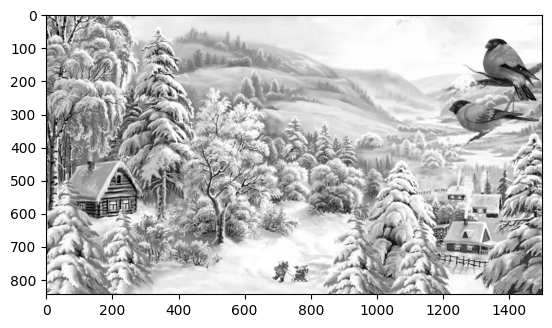

In [8]:
plt.imshow(img, cmap='Greys_r')

In [23]:
U, sigma, Vh = np.linalg.svd(img, full_matrices=True)

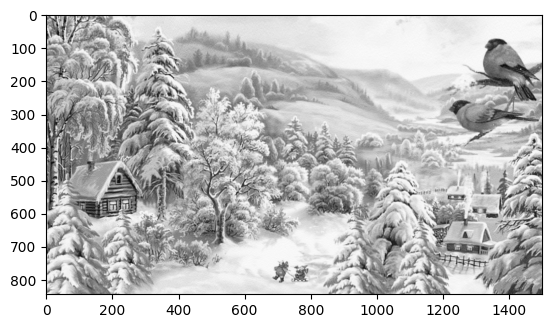

In [24]:
k = min(img.shape) // 4
img_half = U[:, :k] @ np.diag(sigma[:k]) @ Vh[:k, :]
plt.imshow(img_half, cmap='Greys_r')

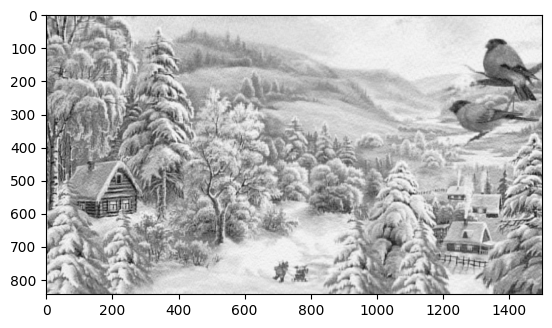

In [25]:
k = min(img.shape) // 8
img_half = U[:, :k] @ np.diag(sigma[:k]) @ Vh[:k, :]
plt.imshow(img_half, cmap='Greys_r')

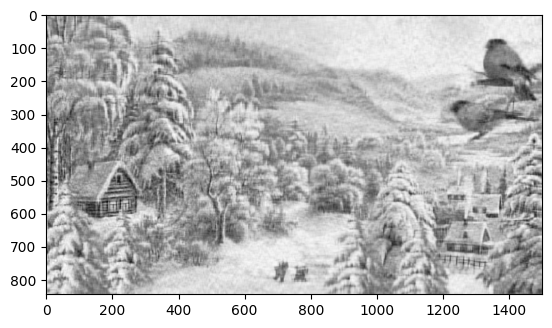

In [26]:
k = min(img.shape) // 16
img_half = U[:, :k] @ np.diag(sigma[:k]) @ Vh[:k, :]
plt.imshow(img_half, cmap='Greys_r')

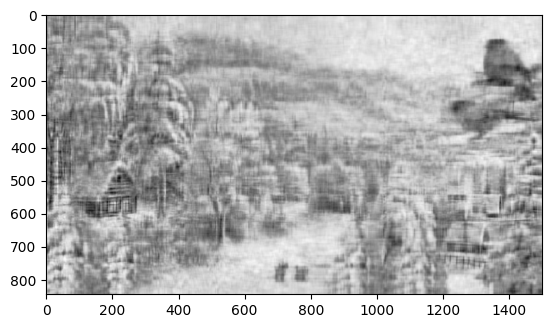

In [27]:
k = min(img.shape) // 32
img_half = U[:, :k] @ np.diag(sigma[:k]) @ Vh[:k, :]
plt.imshow(img_half, cmap='Greys_r')

##Индивидуальное задание

Разведчик решил передать изображение в виде файла xlsx с svd разложением картинки.
Чтобы в случае перехвата сложнее было восстановить картинку, он транспонировал одну из матриц,
а сингулярные числа сделал надписями строк или столбцов одной из матриц.

Считать из файла "alg_13_ind_v_xx.xlsx" матрицы svd разложения,
восстановить и вывести на экран изображение, которое хотел передать разведчик.

In [10]:
file_name = f'/content/alg_13_ind_v_191.xlsx'
U_data = pd.read_excel(file_name, sheet_name=0, header=None).iloc[1:, 1:]
U = np.array(U_data.values)

In [11]:
V_data = pd.read_excel(file_name, sheet_name=1, header=None).iloc[1:, 1:]
V = np.array(V_data.values).T

In [12]:
sigma_data = pd.read_excel(file_name, sheet_name=1, header=None).iloc[1:, 0]
sigma = np.array(sigma_data.values)

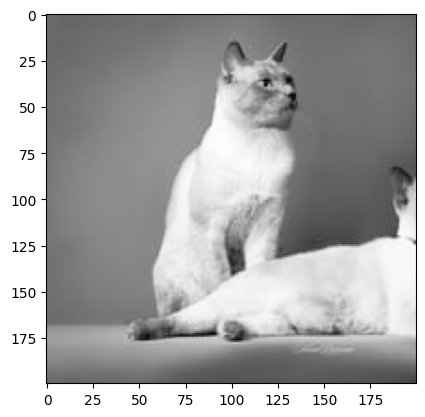

In [17]:
k = min(img.shape)
img_half = U[:, :k] @ np.diag(sigma[:k]) @ V[:k, :]
plt.imshow(img_half, cmap='Greys_r')